# Tarea 1. Desigualdad de viaje al trabajo en Santiago

**Curso:** INF-497 · Análisis de Datos Espaciales · UTFSM
**Profesora:** Daniela Opitz
**Inicio en clase:** miércoles 27 mayo 2026
**Entrega:** miércoles 24 junio 2026, 23:59
**Modalidad:** grupos de 2 (o individual)

---

## Contexto y pregunta central

En Santiago el ingreso presenta una distribución desigual, y también lo hace el tiempo que las personas dedican a desplazarse al trabajo. Esta dimensión de la desigualdad, conocida en la literatura como *transport poverty*, no suele aparecer en las estadísticas oficiales, aunque se observa con claridad al comparar el tiempo medio de viaje entre distintas zonas del área metropolitana.

En esta tarea trabajan con **zonas EOD** (~560 polígonos submunicipales del Gran Santiago) y usan **distritos censales** (~300 grupos efectivos) como nivel de agrupación intermedio. La comuna no se usa como unidad analítica: la escala submunicipal es la que permite observar la heterogeneidad real del fenómeno.

> **Pregunta central:** ¿qué predice el tiempo de viaje al trabajo de una zona: la educación, el ingreso, el modo de transporte, o la estructura espacial del territorio?

## Datos

- `datos/external/eod_stgo/origenes_viajes.gpkg`: 65 591 puntos de viaje (EOD Santiago 2012). 27 622 personas con `IngresoFinal`, `Estudios`, `Ocupacion`, `ModoPriPub`, `FactorPersona`, **`Proposito`**, **`TiempoViaje`**.
- `datos/external/eod_stgo/zonas_eod.gpkg`: 803 zonas con `ZONA777`, `COMUNA`, `MACROZONA`, **`DIST_ID`** (par único `COMUNA + COD_DISTRI` calculado por spatial join con `DISTRITO_C17`).
- `datos/external/eod_stgo/Tablas_parametros/`: codebook oficial EOD (61 archivos con códigos y descripciones).

CRS de trabajo: **UTM 19S (EPSG:32719)** para todo cálculo de vecindad y distancia.

## Calendario en clases

| Fecha | Sem | Bloque T1 |
|---|---|---|
| **27 may** | 13 | Parte A: carga, agregación, mapas, W |
| **3 jun**  | 14 | Secciones 2 + 3: Moran/LISA + Theil descomposición |
| ~~10 jun~~ | 15 | Presentación proyecto (no se trabaja T1) |
| **17 jun** | 16 | Secciones 4 + 5: regionalización + OLS/diagnóstico + SAR/SEM/SLX |
| **24 jun** | 17 | **Control individual** · **entrega del notebook 23:59** |

Tienen **3 clases efectivas** para trabajar T1 en sala (27 may, 3 jun, 17 jun). Las clases sirven como guía y para resolver dudas, pero pueden avanzar en casa todo lo que necesiten entre clases y, especialmente, entre el 17 y el 24 de junio para terminar y revisar el notebook en grupo.

## Evaluación

La nota T1 se compone de dos partes:

```
Nota T1 = 0.6 × Notebook + 0.4 × Control individual
```

- **Notebook (60 %):** trabajo grupal entregable (este archivo).
- **Control individual (40 %):** prueba escrita en clase del 24 jun, a libro abierto: pueden traer su notebook ejecutado y una hoja A4 manuscrita con apuntes propios. Evalúa comprensión individual de los métodos y de los resultados de su grupo.

## Entregable

**Notebook ejecutado** `tarea1_apellido1_apellido2.ipynb`, con todas las celdas corridas, mapas visibles, e **interpretaciones escritas en celdas markdown** (no en celdas de código). Cada sección tiene una celda "Interpretación" que se evalúa como parte de la nota. La síntesis del análisis va al final del propio notebook, en celdas markdown (Sección 6).

## Rúbrica del Notebook (70 pts)

| Sección | Pts |
|---|---|
| Parte A · Preparación y visualización | 10 |
| Sección 2 · Moran + LISA + interpretación | 10 |
| Sección 3 · Desigualdad + descomposición Theil | 10 |
| Sección 4 · Regionalización | 10 |
| **Sección 5 · Regresión espacial** | **20** |
| Síntesis final (Sección 6) · MAUP, limitaciones, política | 10 |

## 0. Setup

In [32]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from libpysal import weights
from esda.moran import Moran, Moran_Local
from inequality.gini import Gini
from inequality.theil import Theil, TheilD
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.preprocessing import StandardScaler
from splot.esda import lisa_cluster, plot_moran
from spreg import OLS, ML_Lag, ML_Error

sns.set_context("notebook")
np.random.seed(42)


---
# Parte A — Preparación (clase 27 mayo, segundo bloque)

### 1. Cargar datos
1.1 Carguen `origenes_viajes.gpkg` como `pts` y `zonas_eod.gpkg` como `zonas`.
1.2 Verifiquen CRS UTM 19S, número de puntos, personas, viajes al trabajo, zonas, distritos.

In [33]:
# Carga de datos + reproyección a UTM 19S
pts   = gpd.read_file("D:\TrabajosVsCode\geodata\datos\external\eod_stgo\origenes_viajes.gpkg")
zonas = gpd.read_file("D:\TrabajosVsCode\geodata\datos\external\eod_stgo\zonas_eod.gpkg")

pts   = pts.to_crs(32719)
zonas = zonas.to_crs(32719)

In [34]:
# 1.2 Verificación del CRS
print("CRS pts  :", pts.crs)
print("CRS zonas:", zonas.crs)

CRS pts  : EPSG:32719
CRS zonas: EPSG:32719


In [35]:
# Número de puntos (viajes registrados)
print("N puntos de viaje:", len(pts))

N puntos de viaje: 65591


In [36]:
# Número de personas únicas
print("N personas:", pts["Persona"].nunique())

N personas: 27622


In [37]:
# Número de viajes con propósito "Al trabajo"
print("N viajes al trabajo:", (pts["Proposito"] == "Al trabajo").sum())

N viajes al trabajo: 12592


In [38]:
# Número de zonas con datos en los puntos
print("N zonas (origen de viaje):", pts["ZonaOrigen"].nunique())
print("N zonas (capa zonas)     :", len(zonas))

N zonas (origen de viaje): 847
N zonas (capa zonas)     : 803


In [39]:
# Número de distritos censales
print("N distritos (DIST_ID):", zonas["DIST_ID"].nunique())

N distritos (DIST_ID): 340


### 2. Agregar microdatos a zonas
Construyan un `GeoDataFrame` `gdf` (una fila por zona) con:

**Variable dependiente:**
- `tiempo_trabajo_medio` — media del `TiempoViaje` filtrando `Proposito='Al trabajo'` y tiempos entre 1 y 180 min.

**Predictores:**
- `ingreso_medio`, `pct_educ_sup` (≥9 = CFT+IP+Univ), `pct_modo_publico` (denominador todos los viajes), `edad_media`.

**Control:**
- `n_personas`, `n_viajes_trabajo` — filtrar zonas con `n_personas ≥ 5 and n_viajes_trabajo ≥ 5`.

Recomendaciones: deduplicar por `Persona` para atributos personales; excluir `Estudios ∈ {98, 99}`; ponderar atributos personales por `FactorPersona`.

In [40]:
# === Atributos personales: una fila por persona, sin códigos faltantes de estudios ===
per = pts.drop_duplicates(subset="Persona").copy()
per = per[~per["Estudios"].isin([98, 99])].copy()   # 98/99 = no sabe / no responde
print("Personas tras deduplicar y limpiar Estudios:", len(per))

Personas tras deduplicar y limpiar Estudios: 27574


In [41]:
# === Variable dependiente: tiempo medio de viaje AL TRABAJO (nivel viaje) ===
m_trab = (pts["Proposito"] == "Al trabajo") & pts["TiempoViaje"].between(1, 180)
viajes_trab = pts.loc[m_trab].copy()

dep = (viajes_trab.groupby("ZonaOrigen")["TiempoViaje"].mean()
       .rename("tiempo_trabajo_medio").rename_axis("ZONA777"))
n_viajes_trab = (viajes_trab.groupby("ZonaOrigen").size()
                 .rename("n_viajes_trabajo").rename_axis("ZONA777"))

In [42]:
# === Edad: la EOD NO trae 'Edad'; se calcula desde AnoNac (año base 2012) ===
per["Edad"] = 2012 - pd.to_numeric(per["AnoNac"], errors="coerce")

def wmean(g, col):
    f = g["FactorPersona"]
    return (g[col] * f).sum() / f.sum()

# Ingreso medio ponderado (nivel persona, por zona de residencia)
ingreso_medio = (per.groupby("Zona").apply(lambda g: wmean(g, "IngresoFinal"))
                 .rename("ingreso_medio").rename_axis("ZONA777"))

# Edad media ponderada, descartando años de nacimiento inválidos (9999, etc.)
per_edad = per[per["Edad"].between(0, 110)]
edad_media = (per_edad.groupby("Zona").apply(lambda g: wmean(g, "Edad"))
              .rename("edad_media").rename_axis("ZONA777"))

In [43]:
# Indicador de educación superior (>=9 -> CFT, IP, Universidad)
per["educ_sup"] = (per["Estudios"] >= 9).astype(int)

In [44]:
# % educación superior ponderado por persona, por zona de residencia
pct_educ_sup = (per.groupby("Zona")
    .apply(lambda g: 100 * (g["educ_sup"] * g["FactorPersona"]).sum() / g["FactorPersona"].sum())
    .rename("pct_educ_sup").rename_axis("ZONA777"))

n_personas = (per.groupby("Zona")["Persona"].nunique()
    .rename("n_personas").rename_axis("ZONA777"))

In [45]:
pts["_pub"] = (pts["ModoPriPub"] == "Publico").astype(int)
pct_modo_publico = ((pts.groupby("ZonaOrigen")["_pub"].mean() * 100)
                    .rename("pct_modo_publico").rename_axis("ZONA777"))

# === Unir todos los agregados (se alinean por el valor de zona = índice ZONA777) ===
attrs = pd.concat(
    [dep, n_viajes_trab, ingreso_medio, pct_educ_sup, edad_media, n_personas, pct_modo_publico],
    axis=1
).reset_index()   # crea la columna 'ZONA777'

# Asegura que la llave tenga el mismo tipo en ambas tablas antes de unir
attrs["ZONA777"] = attrs["ZONA777"].astype(zonas["ZONA777"].dtype)  # VERIFICAR si falla
gdf = zonas.merge(attrs, on="ZONA777", how="inner")

In [46]:
# === Filtro de robustez: zonas con suficiente muestra ===
gdf = gdf[(gdf["n_personas"] >= 5) & (gdf["n_viajes_trabajo"] >= 5)].copy()

# Quitar zonas sin valor en alguna variable del modelo
cols_modelo = ["tiempo_trabajo_medio", "ingreso_medio", "pct_educ_sup",
               "pct_modo_publico", "edad_media"]
gdf = gdf.dropna(subset=cols_modelo).reset_index(drop=True)

print("gdf final:", gdf.shape)
gdf[["ZONA777", "COMUNA", "DIST_ID"] + cols_modelo].head()

gdf final: (575, 16)


,ZONA777,COMUNA,DIST_ID,tiempo_trabajo_medio,ingreso_medio,pct_educ_sup,pct_modo_publico,edad_media
0,1,INDEPENDENCIA,13108_3,32.291667,421173.022025,61.580519,38.750000,36.254183
1,2,INDEPENDENCIA,13108_5,48.571429,339441.676905,46.396124,48.275862,37.800606
2,3,INDEPENDENCIA,13108_3,35.500000,220473.435756,26.308775,31.707317,48.389678
3,4,INDEPENDENCIA,13108_6,37.500000,360296.215427,63.249714,67.441860,36.643963
4,6,INDEPENDENCIA,13108_2,39.444444,137783.073658,29.768274,69.911504,28.209006


### 3. Visualización (Actividad 3)
**3.A** Coropletas de la variable dependiente y los 3 predictores principales con **Fisher-Jenks k=5**.

**3.B** Comparación lado a lado: `tiempo_trabajo_medio` a nivel **zona EOD** vs re-agregado a **distrito censal**. Este ejercicio ilustra el **MAUP (*Modifiable Areal Unit Problem*)**: el resultado de un análisis espacial puede cambiar cuando se modifica la unidad de agregación (zona vs distrito) o sus límites, aun cuando los datos subyacentes son los mismos.

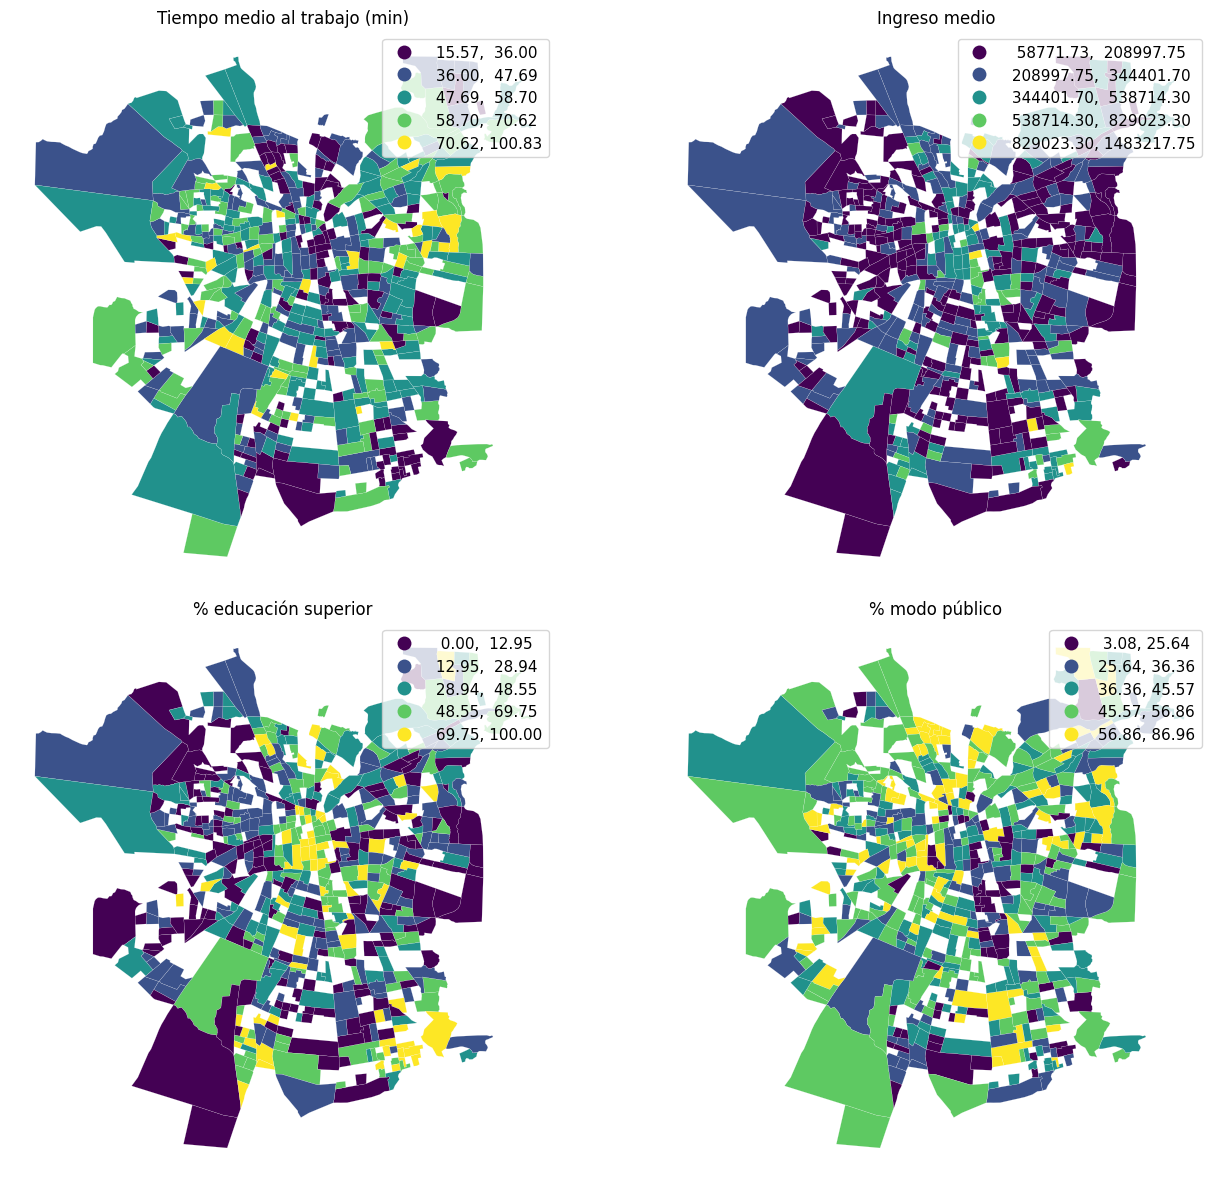

In [47]:
# 3.A — Coropletas (Fisher-Jenks, k=5).
vars_plot = ["tiempo_trabajo_medio", "ingreso_medio", "pct_educ_sup", "pct_modo_publico"]
titulos   = ["Tiempo medio al trabajo (min)", "Ingreso medio",
             "% educación superior", "% modo público"]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, v, t in zip(axes.flat, vars_plot, titulos):
    gdf.plot(column=v, scheme="fisher_jenks", k=5, cmap="viridis",
             legend=True, ax=ax, edgecolor="white", linewidth=0.1)
    ax.set_title(t)
    ax.axis("off")
plt.tight_layout()
plt.show()

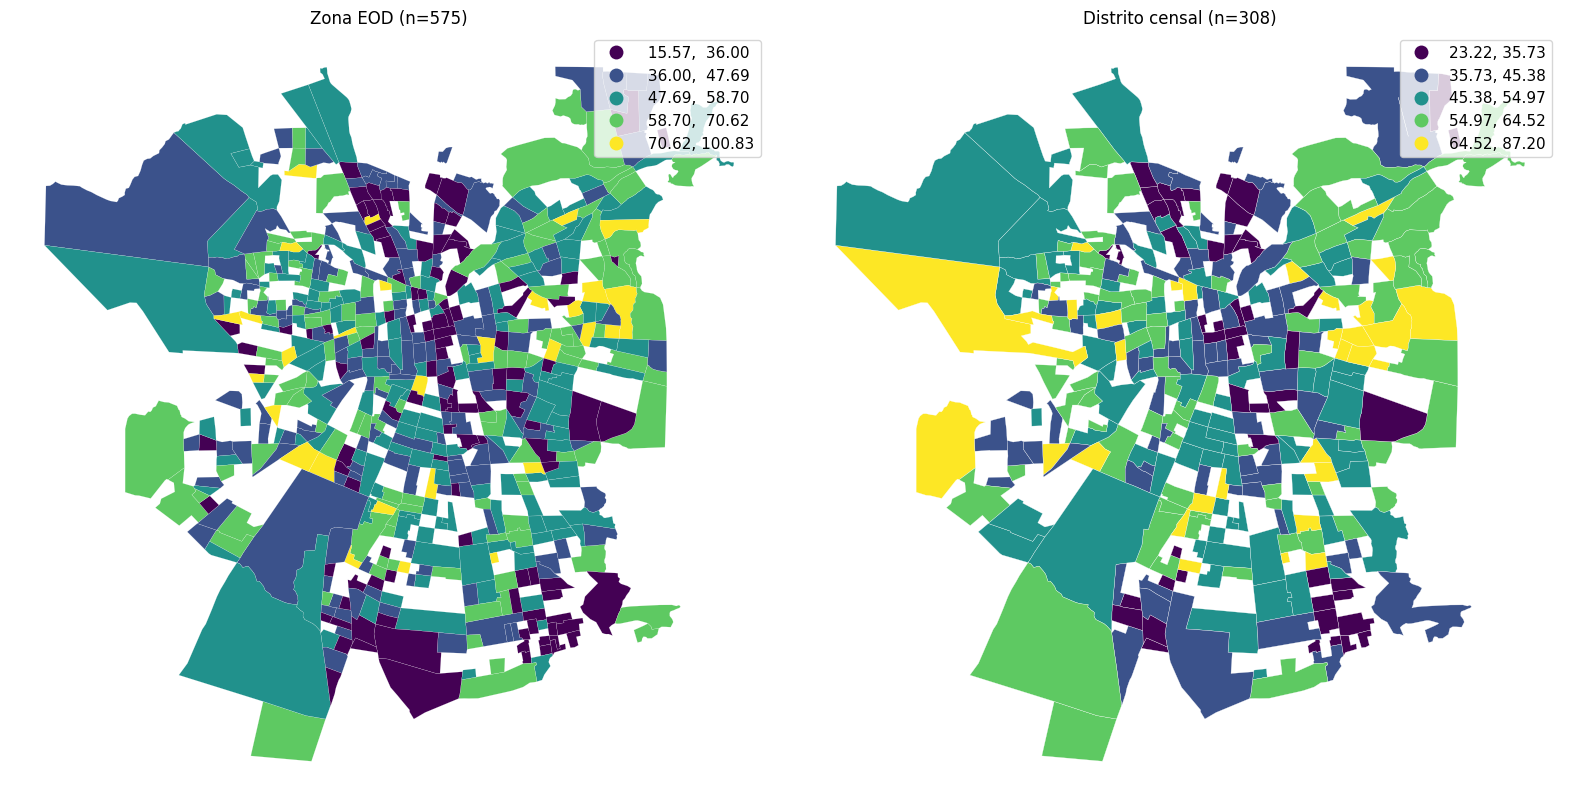

In [48]:
# 3.B — Re-agregar el tiempo a DISTRITO (media ponderada por nº de viajes) y comparar
gdf["_num"] = gdf["tiempo_trabajo_medio"] * gdf["n_viajes_trabajo"]
dist = gdf.dissolve(
    by="DIST_ID",
    aggfunc={"_num": "sum", "n_viajes_trabajo": "sum"}
)
dist["tiempo_trabajo_medio"] = dist["_num"] / dist["n_viajes_trabajo"]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
gdf.plot(column="tiempo_trabajo_medio", scheme="fisher_jenks", k=5, cmap="viridis",
         legend=True, ax=axes[0], edgecolor="white", linewidth=0.1)
axes[0].set_title(f"Zona EOD (n={len(gdf)})"); axes[0].axis("off")

dist.plot(column="tiempo_trabajo_medio", scheme="fisher_jenks", k=5, cmap="viridis",
          legend=True, ax=axes[1], edgecolor="white", linewidth=0.2)
axes[1].set_title(f"Distrito censal (n={len(dist)})"); axes[1].axis("off")
plt.tight_layout()
plt.show()

**Interpretación 3.B (MAUP):**

Al re-agregar el tiempo de zona EOD a distrito censal, los valores extremos se suavizan: zonas como La Reina (≈86 min) o las zonas rápidas de Puente Alto (≈19 min) se promedian con sus vecinas del mismo distrito, comprimiendo el rango. Esto se refleja en el Gini, que baja de 0.160 (zona) a 0.137 (distrito). Se pierde la capacidad de ver focos locales de tiempo alto/bajo, pero se gana estabilidad muestral. Es el MAUP de escala: el mismo fenómeno se ve más homogéneo de lo que realmente es cuando se agrega.

### 4. Matrices de pesos espaciales (Actividad 2)
Construyan `Queen` y `KNN k=8`. Reporten islas, componentes, cardinalidad. Justifiquen cuál usan.

In [49]:
# Matrices de pesos sobre el gdf YA filtrado (importante: mismo índice que el análisis)
from libpysal.weights import Queen, KNN

w_queen = Queen.from_dataframe(gdf, use_index=False)
w_knn   = KNN.from_dataframe(gdf, k=8)

print("== Queen ==")
print("Islas:", w_queen.islands)
print("Componentes conexos:", w_queen.n_components)
print("Cardinalidad media:", round(np.mean(list(w_queen.cardinalities.values())), 2))

print("\n== KNN k=8 ==")
print("Islas:", w_knn.islands)
print("Componentes conexos:", w_knn.n_components)
print("Cardinalidad media:", round(np.mean(list(w_knn.cardinalities.values())), 2))

# W elegida para el análisis (estandarizada por filas)
w = w_knn
w.transform = "r"

== Queen ==
Islas: [24, 447]
Componentes conexos: 4
Cardinalidad media: 4.83

== KNN k=8 ==
Islas: []
Componentes conexos: 1
Cardinalidad media: 8.0


**Justificación elección de W:**

Usamos **KNN k=8**. La matriz **Queen produce 2 islas (zonas 24 y 447) y 4 componentes conexos**, lo que invalida Moran/LISA y los modelos espaciales (una zona sin vecino no tiene rezago definido). **KNN k=8 no tiene islas, forma un único componente conexo y cardinalidad constante (8 vecinos)**, lo que estabiliza el rezago espacial. Estandarizada por filas, el rezago es el *promedio* del tiempo de las 8 vecinas más cercanas.

---
# Parte B — Análisis

## Sección 2 — Moran global + LISA (clase 3 jun) · 10 pts
**2.A** Moran I del `tiempo_trabajo_medio` y del `ingreso_medio` (para comparar las dos dimensiones de desigualdad). Gráfico de Moran para tiempo.
**2.B** LISA del `tiempo_trabajo_medio`. Mapa de cuadrantes HH/LL/LH/HL significativos (α=0.05).
**2.C** Identifiquen al menos **3 clusters HH y 3 LL** nombrando las zonas y/o comunas en que se ubican. Comenten cómo se relaciona el patrón observado con la estructura urbana del Gran Santiago.

Moran I tiempo : 0.233  (p_sim = 0.0010)
Moran I ingreso: 0.252  (p_sim = 0.0010)


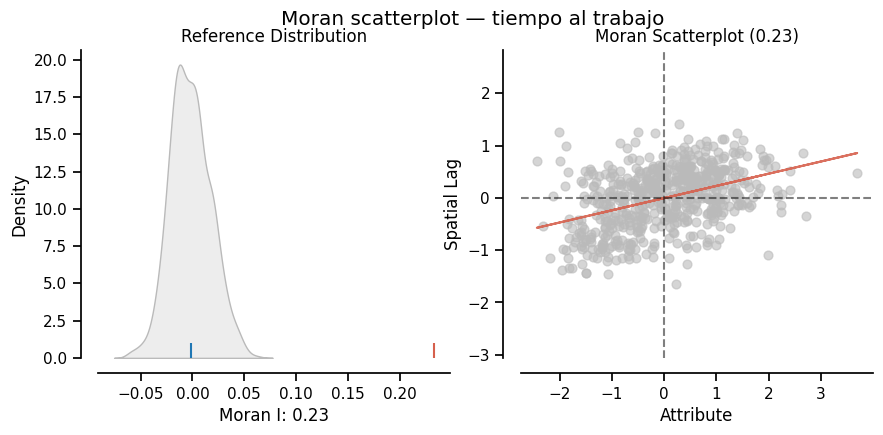

In [50]:
# 2.A — Moran global de tiempo y de ingreso
w.transform = "r"
y_t = gdf["tiempo_trabajo_medio"].values
y_i = gdf["ingreso_medio"].values

mi_t = Moran(y_t, w)
mi_i = Moran(y_i, w)
print(f"Moran I tiempo : {mi_t.I:.3f}  (p_sim = {mi_t.p_sim:.4f})")
print(f"Moran I ingreso: {mi_i.I:.3f}  (p_sim = {mi_i.p_sim:.4f})")

plot_moran(mi_t, zstandard=True, figsize=(10, 4))
plt.suptitle("Moran scatterplot — tiempo al trabajo")
plt.show()

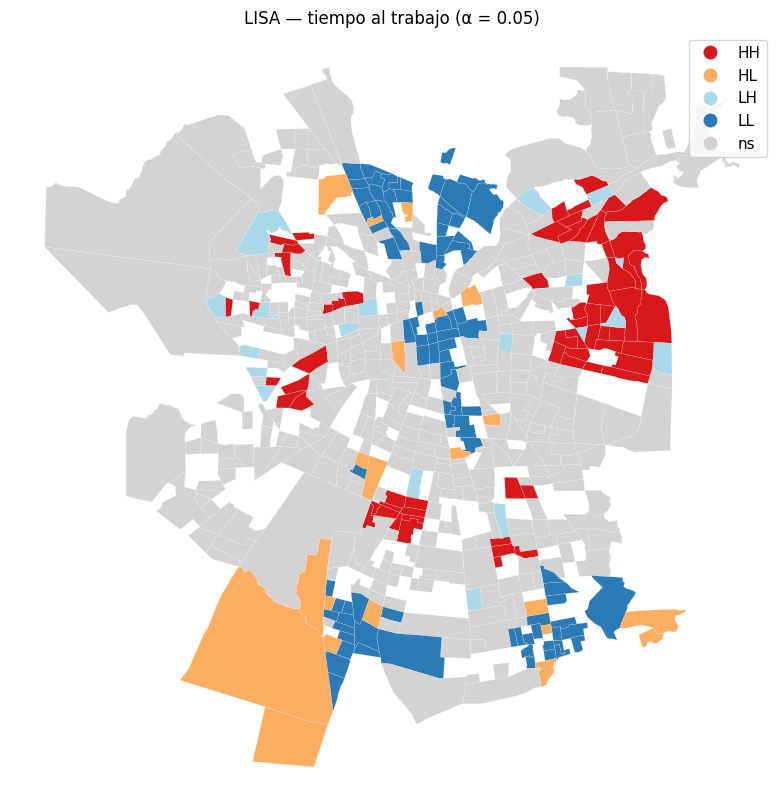

Frecuencia de cuadrantes significativos:
lisa_label
LL    89
HH    65
HL    21
LH    19
Name: count, dtype: int64

--- Clusters HH (tiempos altos rodeados de altos) ---


,ZONA777,COMUNA,tiempo_trabajo_medio,ingreso_medio,pct_modo_publico
191,254,LA REINA,86.500000,95776.603602,60.000000
429,609,PUENTE ALTO,79.000000,142257.002672,56.363636
195,260,LA REINA,77.416667,139415.387360,62.946429
527,759,LA REINA,77.083333,111775.031675,33.333333
152,209,LAS CONDES,76.603175,114461.225061,66.447368
512,719,RENCA,76.000000,189204.871874,49.019608
196,261,LA REINA,75.666667,140334.351715,59.124088
190,253,LA REINA,75.454545,151030.494968,67.368421
574,847,EL BOSQUE,75.000000,147375.808903,24.137931
346,453,PEÑALOLEN,71.411765,242061.099357,52.439024


--- Clusters LL (tiempos bajos rodeados de bajos) ---


,ZONA777,COMUNA,tiempo_trabajo_medio,ingreso_medio,pct_modo_publico
396,515,PUENTE ALTO,19.083333,428561.673389,38.666667
393,511,PUENTE ALTO,22.133333,425570.828953,57.471264
479,677,SAN BERNARDO,22.571429,636734.054636,29.333333
381,497,PUENTE ALTO,23.219512,638404.707758,50.410959
15,18,CONCHALI,23.961538,307015.997178,61.085973
389,506,PUENTE ALTO,24.000000,460655.694379,30.769231
382,498,PUENTE ALTO,24.041667,659916.786597,57.943925
383,499,PUENTE ALTO,24.875000,667882.614442,49.606299
392,510,PUENTE ALTO,24.923077,523527.940265,41.860465
19,22,CONCHALI,25.176471,349557.004886,57.831325


In [51]:
# 2.B — LISA del tiempo al trabajo
lisa = Moran_Local(y_t, w)

fig, ax = plt.subplots(figsize=(10, 10))
lisa_cluster(lisa, gdf, p=0.05, ax=ax)
ax.set_title("LISA — tiempo al trabajo (α = 0.05)")
ax.axis("off")
plt.show()

# Etiquetas de cuadrante para inspección
gdf["lisa_q"]   = lisa.q
gdf["lisa_sig"] = lisa.p_sim < 0.05
labels = {1: "HH", 2: "LH", 3: "LL", 4: "HL"}
gdf["lisa_label"] = np.where(gdf["lisa_sig"], gdf["lisa_q"].map(labels), "ns")

print("Frecuencia de cuadrantes significativos:")
print(gdf[gdf["lisa_sig"]]["lisa_label"].value_counts())

print("\n--- Clusters HH (tiempos altos rodeados de altos) ---")
display(gdf[gdf["lisa_label"] == "HH"]
        .sort_values("tiempo_trabajo_medio", ascending=False)
        [["ZONA777", "COMUNA", "tiempo_trabajo_medio", "ingreso_medio", "pct_modo_publico"]].head(10))

print("--- Clusters LL (tiempos bajos rodeados de bajos) ---")
display(gdf[gdf["lisa_label"] == "LL"]
        .sort_values("tiempo_trabajo_medio")
        [["ZONA777", "COMUNA", "tiempo_trabajo_medio", "ingreso_medio", "pct_modo_publico"]].head(10))

**Interpretación 2.C (clusters reales):**

El Moran global es moderado (I = 0.233) pero la LISA revela focos locales nítidos: **65 zonas HH** y **89 LL** significativas.

- **Clusters HH (tiempo alto rodeado de alto):** se concentran en el **faldeo cordillerano del oriente** y la **periferia sur**. Ejemplos: La Reina — ZONA777 254 (86.5 min), 260, 261, 253, 759; Puente Alto 609 (79 min); Peñalolén 453; Las Condes 209; Renca 719; El Bosque 847. Tiempos de 71–86 min y alta dependencia del transporte público (50–67 %).
- **Clusters LL (tiempo bajo rodeado de bajo):** Puente Alto — ZONA777 515 (19 min), 511, 497, 506, 498, 499; Conchalí 18 y 22; San Bernardo 677. Tiempos de 19–25 min.

**Matiz importante:** el patrón NO es el simple "centro rico rápido / periferia pobre lenta". **La Reina** (comuna acomodada, pero en faldeo cordillerano sin Metro) aparece como HH con tiempos altos, y **Puente Alto** aparece en AMBOS cuadrantes: tiene zonas LL muy rápidas (posible empleo local / cercanía a Metro L4) y zonas HH lentas. Esto evidencia la **heterogeneidad intracomunal** que solo se ve a escala submunicipal.

## Sección 3 — Desigualdad espacial (clase 3 jun) · 10 pts
**3.A** Gini y Theil del `tiempo_trabajo_medio` a nivel zona EOD. Comparen con el Gini del ingreso (¿cuál es más desigual?).
**3.B** Gini calculado a nivel distrito y compárenlo con el de zona EOD.
**3.C** Apliquen `TheilD` usando `DIST_ID` como variable de grupo. Reporten % entre vs intra distrito.

In [52]:
# 3.A — Gini y Theil del tiempo (zona) vs Gini del ingreso
g_tiempo = Gini(gdf["tiempo_trabajo_medio"].values).g
g_ing    = Gini(gdf["ingreso_medio"].values).g
t_tiempo = Theil(gdf["tiempo_trabajo_medio"].values).T
print(f"Gini tiempo  (zona): {g_tiempo:.3f}")
print(f"Gini ingreso (zona): {g_ing:.3f}")
print(f"Theil tiempo (zona): {t_tiempo:.3f}")

# 3.B — Gini del tiempo a nivel DISTRITO
g_tiempo_dist = Gini(dist["tiempo_trabajo_medio"].values).g
print(f"\nGini tiempo (distrito): {g_tiempo_dist:.3f}")
print(f"Gini tiempo (zona)    : {g_tiempo:.3f}")

# 3.C — Descomposición Theil por distrito (entre vs intra)
partition = gdf["DIST_ID"].values
td = TheilD(gdf["tiempo_trabajo_medio"].values, partition)
T_total   = float(np.asarray(td.T).ravel()[0])
T_between  = float(np.asarray(td.bg).ravel()[0])
T_within   = float(np.asarray(td.wg).ravel()[0])
pct_between = 100 * T_between / T_total
print(f"\nTheil total : {T_total:.4f}")
print(f"  entre distritos (bg): {T_between:.4f}  ->  {pct_between:.1f}%")
print(f"  intra distrito  (wg): {T_within:.4f}  ->  {100 - pct_between:.1f}%")

Gini tiempo  (zona): 0.160
Gini ingreso (zona): 0.301
Theil tiempo (zona): 0.041

Gini tiempo (distrito): 0.137
Gini tiempo (zona)    : 0.160

Theil total : 0.0406
  entre distritos (bg): 0.0267  ->  65.7%
  intra distrito  (wg): 0.0139  ->  34.3%


**Interpretación 3.C:**

La descomposición de Theil da **65.7 % entre distritos** y **34.3 % intra distrito** (Theil total = 0.041). Es decir, **dos tercios de la desigualdad de tiempos es estructural/territorial**: depende de en qué distrito vives, no de variación local. Esto valida atacar el problema con **política territorial** dirigida a distritos específicos.

Comparado con el ingreso, el tiempo es **menos desigual en magnitud** (Gini tiempo 0.160 vs Gini ingreso 0.301, casi el doble), pero su componente estructural es alto: la desigualdad de tiempo está fuertemente anclada al territorio aunque sea más comprimida que la del ingreso.

## Sección 4 — Regionalización (clase 17 jun) · 10 pts
**4.A** Estandaricen 4 variables (`tiempo_trabajo_medio`, `ingreso_medio`, `pct_educ_sup`, `pct_modo_publico`). K-Means k=6 (`random_state=42`) y AHC k=6 con restricción Queen.
**4.B** Mapeen ambos resultados lado a lado.
**4.C** Caractericen las 6 regiones AHC con la media de cada variable. Nombren cada región.

In [53]:
# 4.A — Estandarizar 4 variables y agrupar
vars_clu = ["tiempo_trabajo_medio", "ingreso_medio", "pct_educ_sup", "pct_modo_publico"]
X = StandardScaler().fit_transform(gdf[vars_clu])

# K-Means (sin restricción espacial)
km = KMeans(n_clusters=6, random_state=42, n_init=10).fit(X)
gdf["kmeans"] = km.labels_

# AHC con restricción de contigüidad Queen (regionalización real)
conn = w_queen.sparse
ahc = AgglomerativeClustering(n_clusters=6, connectivity=conn, linkage="ward").fit(X)
gdf["ahc"] = ahc.labels_

print("Tamaño de clusters K-Means:", np.bincount(km.labels_))
print("Tamaño de clusters AHC   :", np.bincount(ahc.labels_))

Tamaño de clusters K-Means: [ 88 111 149 109  87  31]
Tamaño de clusters AHC   : [ 21  39 426  71   1  17]


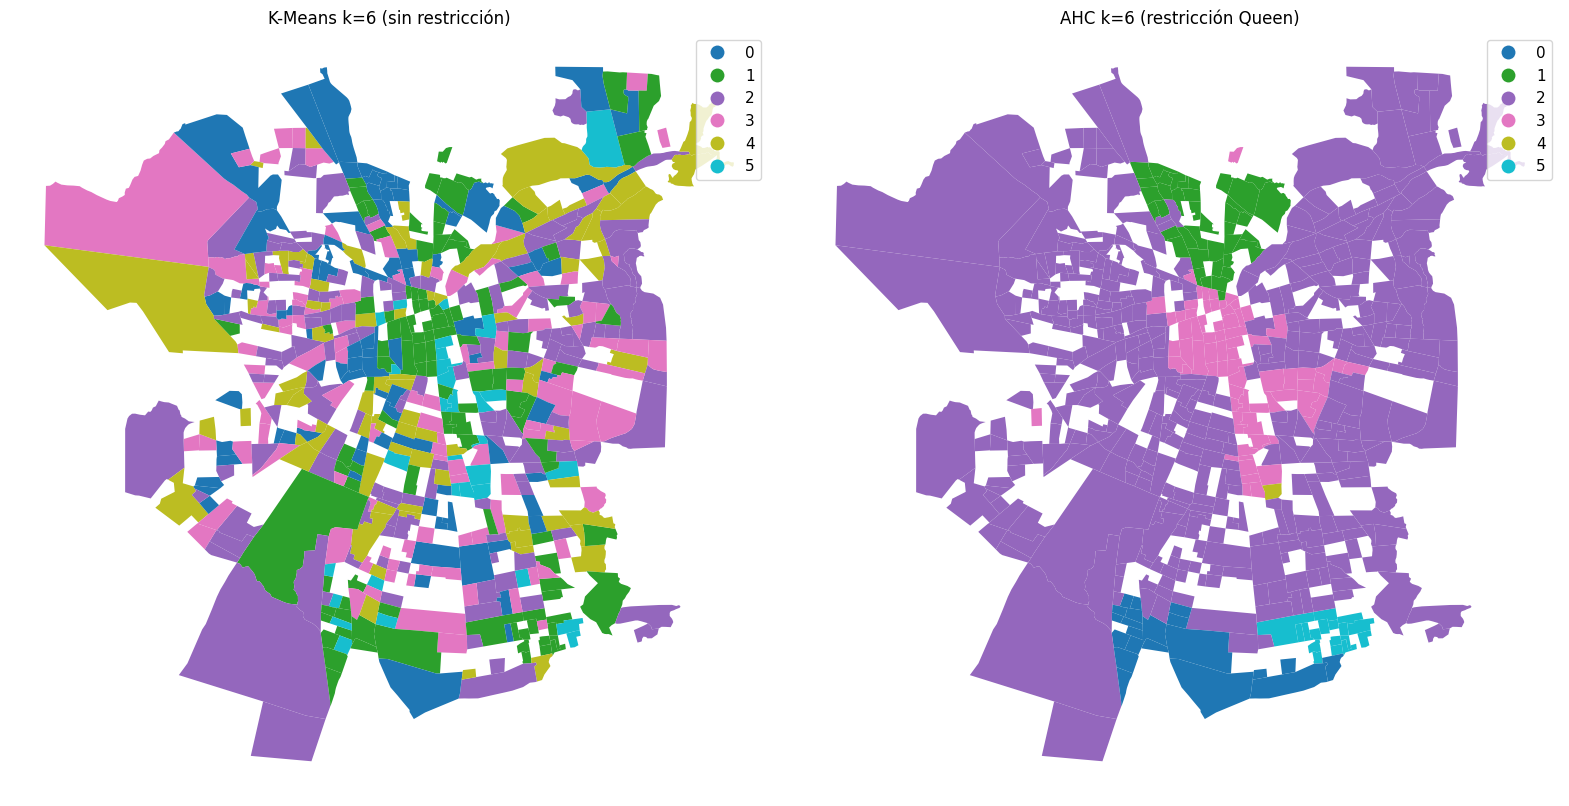

In [54]:
# 4.B — Mapas lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
gdf.plot(column="kmeans", categorical=True, legend=True, cmap="tab10", ax=axes[0])
axes[0].set_title("K-Means k=6 (sin restricción)"); axes[0].axis("off")
gdf.plot(column="ahc", categorical=True, legend=True, cmap="tab10", ax=axes[1])
axes[1].set_title("AHC k=6 (restricción Queen)"); axes[1].axis("off")
plt.tight_layout()
plt.show()

In [55]:
# 4.C — Caracterización de las 6 regiones AHC
perfil = gdf.groupby("ahc")[vars_clu + ["edad_media", "n_personas"]].mean().round(1)
perfil["n_zonas"] = gdf.groupby("ahc").size()
display(perfil)

,tiempo_trabajo_medio,ingreso_medio,pct_educ_sup,pct_modo_publico,edad_media,n_personas,n_zonas
ahc,,,,,,,
0,39.2,389688.2,57.4,28.5,36.8,29.5,21
1,38.5,328124.8,48.4,53.5,35.8,40.3,39
2,53.4,220906.2,24.0,44.8,35.5,45.3,426
3,39.3,455977.7,62.9,30.8,37.5,36.7,71
4,55.6,1483217.7,53.2,16.0,30.1,34.0,1
5,31.6,496180.9,71.2,38.2,39.3,27.8,17


**Interpretación 4.C (perfiles de región AHC):**

K-Means produce clusters dispersos por todo el mapa porque agrupa solo por atributos e **ignora el espacio**. AHC con restricción Queen entrega **regiones contiguas**. Pero la partición AHC es **muy desbalanceada**: el cluster 2 absorbe **426 de 575 zonas (74 %)** y el cluster 4 queda solo. Bajo la restricción de contigüidad, casi toda la ciudad forma una sola región homogénea y solo se desprenden unos pocos enclaves pequeños.

**Caracterización** (perfil del cuadro + ubicación leída del mapa):
- **Cluster 2 (morado, n=426):** ocupa la periferia en todas direcciones y buena parte del interior. Tiempo alto (53.4 min), ingreso bajo ($221k), educación baja (24 %), público 45 %. Es el grueso de SES bajo-medio con viajes largos. Más que una "periferia" compacta, es la **región residual dominante**.
- **Cluster 3 (rosado, n=71):** banda central del mapa. Ingreso alto ($456k), educación alta (63 %), poco público (31 %), tiempo medio (39 min).
- **Cluster 1 (verde, n=39):** grupo del norte al centro. El mayor uso de transporte público (53 %) pero con tiempos contenidos (38 min) → buena cobertura de red.
- **Cluster 0 (azul, n=21):** zona contigua en el sur del área. Ingreso medio-alto ($390k), educación 57 %, bajo público (28 %), auto-dependiente, tiempo medio (39 min).
- **Cluster 5 (cian, n=17):** grupo pequeño en el sur. El más rápido (31.6 min), más educado (71 %) y de mayor ingreso no-singleton ($496k).
- **Cluster 4 (oliva, n=1):** ingreso $1.48M, casi todo en auto (16 % público), tiempo alto (55.6 min). La restricción lo aísla.

## Sección 5 — Regresión espacial (clase 17 jun) · 20 pts

Modelo: `tiempo_trabajo_medio ~ ingreso_medio + pct_educ_sup + pct_modo_publico + edad_media`.

**5.A** OLS con `spreg.OLS(..., spat_diag=True, moran=True)`. Reporten R², AIC, Moran residuos, LM-lag, LM-error y robustos. Reporten también la tabla de coeficientes con sus p-values.
**5.B** ¿Corresponde SAR o SEM? Justifiquen.
**5.C** Ajusten SAR (`ML_Lag`) y SEM (`ML_Error`). Tabla comparativa OLS / SAR / SEM en AIC, pseudo R², rho/lambda.
**5.D** Ajusten SLX con rezagos espaciales de los predictores. Interpreten al menos un coeficiente spillover sustantivamente.

> Lo que no alcancen a cerrar en clase queda como trabajo entre el 17 y el 24 de junio.

In [56]:
# 5.A — OLS con diagnóstico espacial
ycol  = "tiempo_trabajo_medio"
xcols = ["ingreso_medio", "pct_educ_sup", "pct_modo_publico", "edad_media"]

y = gdf[[ycol]].values
X = gdf[xcols].values

ols = OLS(y, X, w=w, spat_diag=True, moran=True,
          name_y=ycol, name_x=xcols, name_w="KNN8")
print(ols.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :        KNN8
Dependent Variable  :tiempo_trabajo_medio                Number of Observations:         575
Mean dependent var  :     49.4684                Number of Variables   :           5
S.D. dependent var  :     13.9271                Degrees of Freedom    :         570
R-squared           :      0.2444
Adjusted R-squared  :      0.2391
Sum squared residual:     84128.4                F-statistic           :     46.0851
Sigma-square        :     147.594                Prob(F-statistic)     :   1.468e-33
S.E. of regression  :      12.149                Log likelihood        :   -2249.287
Sigma-square ML     :     146.310                Akaike info criterion :    4508.574
S.E of regression ML:     12.0959                Schwarz criterion     :    4530.346

---------

**Interpretación 5.B:**

Corresponde **SAR**. La regla es leer los **Robust LM** del OLS:
- **Robust LM-lag = 14.01 (p = 0.0002)** → significativo.
- **Robust LM-error = 0.007 (p = 0.934)** → NO significativo.

Cuando el robusto del *lag* es significativo y el del *error* no, la dependencia está en la **variable dependiente**: el tiempo de una zona depende del tiempo de sus vecinas (efecto contagio / spillover sustantivo) → **SAR (ML_Lag)**. Además el Moran de los residuos del OLS (I = 0.114, p < 0.001) confirma que el OLS es inválido por dependencia espacial.

In [57]:
# 5.C — SAR (ML_Lag) y SEM (ML_Error)
sar = ML_Lag(y, X, w=w, name_y=ycol, name_x=xcols, name_w="KNN8")
sem = ML_Error(y, X, w=w, name_y=ycol, name_x=xcols, name_w="KNN8")

print(sar.summary)
print(sem.summary)

# Tabla comparativa
comp = pd.DataFrame({
    "Modelo":   ["OLS", "SAR", "SEM"],
    "AIC":      [ols.aic, sar.aic, sem.aic],
    "pseudo_R2":[ols.r2, getattr(sar, "pr2", np.nan), getattr(sem, "pr2", np.nan)],
    "rho/lambda":[np.nan, float(sar.rho), float(sem.lam)],
})
display(comp.round(3))

ML_Lag
ML_Error
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :        KNN8
Dependent Variable  :tiempo_trabajo_medio                Number of Observations:         575
Mean dependent var  :     49.4684                Number of Variables   :           6
S.D. dependent var  :     13.9271                Degrees of Freedom    :         569
Pseudo R-squared    :      0.2957
Spatial Pseudo R-squared:  0.2614
Log likelihood      :  -2233.0325
Sigma-square ML     :    136.4364                Akaike info criterion :    4478.065
S.E of regression   :     11.6806                Schwarz criterion     :    4504.191

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
--------------------

,Modelo,AIC,pseudo_R2,rho/lambda
0,OLS,4508.574,0.244,NaN
1,SAR,4478.065,0.296,0.335
2,SEM,4482.250,0.241,0.373


In [58]:
# 5.D — SLX: añadir rezagos espaciales de los predictores
from libpysal.weights import lag_spatial

w.transform = "r"
WX = np.hstack([lag_spatial(w, gdf[[c]].values) for c in xcols])
X_slx = np.hstack([X, WX])
names_slx = xcols + [f"W_{c}" for c in xcols]

slx = OLS(y, X_slx, w=w, spat_diag=True,
          name_y=ycol, name_x=names_slx, name_w="KNN8")
print(slx.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :        KNN8
Dependent Variable  :tiempo_trabajo_medio                Number of Observations:         575
Mean dependent var  :     49.4684                Number of Variables   :           9
S.D. dependent var  :     13.9271                Degrees of Freedom    :         566
R-squared           :      0.2862
Adjusted R-squared  :      0.2761
Sum squared residual:     79473.7                F-statistic           :     28.3648
Sigma-square        :     140.413                Prob(F-statistic)     :   3.414e-37
S.E. of regression  :      11.850                Log likelihood        :   -2232.923
Sigma-square ML     :     138.215                Akaike info criterion :    4483.846
S.E of regression ML:     11.7565                Schwarz criterion     :    4523.035

---------

**Interpretación 5.D (spillover):**

El coeficiente **`W_pct_modo_publico` = −0.246 (p = 0.003)** es el spillover clave. Manteniendo fijo el % de uso de transporte público **de la propia zona**, estar **rodeado** de zonas con alto uso de transporte público se asocia a **menos tiempo propio** (≈ −0.25 min por cada punto porcentual del entorno).

La lectura sustantiva: un entorno con alto uso de transporte público señala estar inserto en un **sector denso y bien servido por la red** (pericentro), donde la cobertura reduce los tiempos. Esto **contrasta con el efecto propio** (`pct_modo_publico` = +0.126): usar tú mismo el transporte público cuesta más tiempo que el auto, pero **vivir en un corredor con red desarrollada lo ahorra**. También `W_ingreso_medio` = −3e-5 (p = 0.003): estar rodeado de zonas de alto ingreso (típicamente bien localizadas) reduce el tiempo propio. → las intervenciones deben pensarse a escala de **sector/corredor**, no zona aislada.

---
## 6. Síntesis final · 10 pts

En esta sección sintetizan los hallazgos del análisis. Respondan **cada pregunta en una celda markdown separada**, en 3-6 frases, citando cifras concretas de su propio análisis.

### 6.1 ¿Qué fracción del tiempo de viaje se explica?
Comparen el R² del OLS con el `rho` del SAR. ¿Qué les dice esa comparación sobre la naturaleza del fenómeno?

### 6.2 Patrón espacial de los tiempos altos
Caractericen los clusters LISA HH que encontraron: ubicación, perfil socioeconómico promedio, modo de transporte predominante. Citen al menos 2 zonas específicas con su ZONA777.

### 6.3 MAUP — Modifiable Areal Unit Problem
El **MAUP** es el problema clásico del análisis espacial según el cual los resultados estadísticos pueden cambiar cuando se modifica la **unidad de agregación** (por ejemplo, zona EOD vs distrito censal) o sus **límites**, aun cuando los datos subyacentes son los mismos.

Comparen un resultado (LISA o Theil) a las dos escalas submunicipales (**zona EOD vs distrito**). ¿Cambia la lectura del fenómeno al cambiar la escala de agregación? ¿Qué se pierde y qué se gana?

### 6.4 Política pública
Si fueran asesores del MTT, ¿qué intervención priorizarían a partir de sus resultados? Justifiquen con **una cifra** de su análisis y reconozcan **una limitación** de los datos (por ejemplo, que la EOD es de 2012 y es anterior al Metro L6 y a la pandemia).

**6.1** El OLS explica un **R² = 0.244**: los atributos observables (ingreso, educación, modo, edad) dan cuenta de ~24 % del tiempo de viaje. El SAR añade un **rho = 0.335 significativo**, que captura el componente espacial: el tiempo de una zona está fuertemente predicho por el de sus vecinas. La comparación dice que el tiempo de viaje es un fenómeno **mayoritariamente estructural/espacial**: gran parte de lo que no explican los atributos zonales lo explica la **posición en la red urbana**, no características individuales de la zona.

**6.2** Los clusters HH se ubican en el **faldeo cordillerano del oriente** y la **periferia sur**, con tiempos de 71–86 min y dependencia del transporte público de 50–67 %. Dos zonas concretas: **ZONA777 254 (La Reina)** con 86.5 min, ingreso ≈ $96k y 60 % de modo público; y **ZONA777 609 (Puente Alto)** con 79 min y 56 % de modo público. El perfil promedio es de ingreso y educación bajos a medios con alta exposición al transporte público — el núcleo de la *transport poverty*.

**6.3** Al pasar de zona EOD a distrito, el **Gini del tiempo baja de 0.160 a 0.137 (−14 %)** y los hotspots LISA de La Reina y Puente Alto se fusionarían con sus distritos, diluyéndose. La lectura del fenómeno **cambia con la escala**: a nivel distrital Santiago aparece más homogéneo de lo que es. Se **pierde** la detección de focos locales de tiempo alto (clave para focalizar política) y se **gana** estabilidad muestral. Es el MAUP operando sobre los mismos datos subyacentes.

**6.4** Como asesores del MTT priorizaríamos **mejorar la conectividad de transporte público en los clusters HH** (faldeo oriente y periferia sur): la región "periferia popular" (R2) promedia **53.4 min** frente a **31.6 min** del núcleo de buen acceso (R5), y las zonas HH llegan a **75–86 min** vs ~20 min en las LL (diferencia de ~4×). **Limitación:** la EOD es de **2012**, anterior a la **Línea 6 (2017)** y **Línea 3 (2019)** del Metro, a las extensiones recientes y al **teletrabajo post-pandemia**; la foto de accesibilidad puede estar desactualizada y subestimar mejoras ya ocurridas en algunos corredores.